In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt

## 📊 GENERATE SAMPLE DATASET

In [2]:
print("🔥 NAIVE BAYES IMPLEMENTATION DEMO")
print("=" * 50)

# Create synthetic dataset
X, y = make_classification(n_samples=1000, n_features=4, n_classes=3, 
                          n_informative=3, n_redundant=1, random_state=42)

# Convert to DataFrame for better visualization
feature_names = ['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
df = pd.DataFrame(X, columns=feature_names)
df['Target'] = y

print("📋 Dataset Info:")
print(f"Shape: {df.shape}")
print(f"Classes: {np.unique(y)}")
print(f"Class distribution: {np.bincount(y)}")
print("\n" + "="*50)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


🔥 NAIVE BAYES IMPLEMENTATION DEMO
📋 Dataset Info:
Shape: (1000, 5)
Classes: [0 1 2]
Class distribution: [334 334 332]



## 🛠️ SKLEARN IMPLEMENTATION

In [3]:
print("\n🚀 SKLEARN NAIVE BAYES")
print("=" * 30)

# Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_sklearn = gnb.predict(X_test)

print(f"✅ Sklearn Accuracy: {accuracy_score(y_test, y_pred_sklearn):.4f}")
print(f"📊 Predictions sample: {y_pred_sklearn[:10]}")
print(f"🎯 Actual sample:     {y_test[:10]}")


🚀 SKLEARN NAIVE BAYES
✅ Sklearn Accuracy: 0.7033
📊 Predictions sample: [0 2 0 1 2 1 2 0 1 2]
🎯 Actual sample:     [1 2 0 1 2 0 2 0 1 1]


## 🔧 NAIVE BAYES FROM SCRATCH

In [4]:
print("\n🔨 NAIVE BAYES FROM SCRATCH")
print("=" * 35)

class NaiveBayesFromScratch:
    def __init__(self):
        self.classes = None
        self.class_priors = {}
        self.feature_stats = {}  # {class: {feature_idx: (mean, var)}}
    
    def fit(self, X, y):
        self.classes = np.unique(y)
        n_samples = X.shape[0]
        
        # Calculate class priors P(y)
        for cls in self.classes:
            self.class_priors[cls] = np.sum(y == cls) / n_samples
        
        # Calculate feature statistics for each class
        for cls in self.classes:
            X_cls = X[y == cls]
            self.feature_stats[cls] = {}
            
            for feature_idx in range(X.shape[1]):
                feature_values = X_cls[:, feature_idx]
                mean = np.mean(feature_values)
                var = np.var(feature_values) + 1e-9  # Add small value to avoid division by zero
                self.feature_stats[cls][feature_idx] = (mean, var)
    
    def _gaussian_pdf(self, x, mean, var):
        """Calculate Gaussian probability density function"""
        return (1 / np.sqrt(2 * np.pi * var)) * np.exp(-0.5 * ((x - mean) ** 2) / var)
    
    def _predict_sample(self, x):
        """Predict single sample"""
        posteriors = {}
        
        for cls in self.classes:
            # Start with prior probability
            posterior = np.log(self.class_priors[cls])
            
            # Add log likelihood for each feature
            for feature_idx in range(len(x)):
                mean, var = self.feature_stats[cls][feature_idx]
                likelihood = self._gaussian_pdf(x[feature_idx], mean, var)
                posterior += np.log(likelihood + 1e-10)  # Add small value to avoid log(0)
            
            posteriors[cls] = posterior
        
        # Return class with highest posterior
        return max(posteriors, key=posteriors.get)
    
    def predict(self, X):
        """Predict multiple samples"""
        return np.array([self._predict_sample(x) for x in X])
    
    def predict_proba(self, X):
        """Get prediction probabilities"""
        probabilities = []
        for x in X:
            posteriors = {}
            for cls in self.classes:
                posterior = np.log(self.class_priors[cls])
                for feature_idx in range(len(x)):
                    mean, var = self.feature_stats[cls][feature_idx]
                    likelihood = self._gaussian_pdf(x[feature_idx], mean, var)
                    posterior += np.log(likelihood + 1e-10)
                posteriors[cls] = posterior
            
            # Convert log probabilities to probabilities
            max_log_prob = max(posteriors.values())
            exp_probs = {cls: np.exp(prob - max_log_prob) for cls, prob in posteriors.items()}
            total = sum(exp_probs.values())
            normalized_probs = {cls: prob/total for cls, prob in exp_probs.items()}
            
            probabilities.append([normalized_probs[cls] for cls in sorted(self.classes)])
        
        return np.array(probabilities)


🔨 NAIVE BAYES FROM SCRATCH


## TRAINING

In [5]:
custom_nb = NaiveBayesFromScratch()
custom_nb.fit(X_train, y_train)
y_pred_custom = custom_nb.predict(X_test)

print(f"✅ Custom Accuracy: {accuracy_score(y_test, y_pred_custom):.4f}")
print(f"📊 Predictions sample: {y_pred_custom[:10]}")

✅ Custom Accuracy: 0.7033
📊 Predictions sample: [0 2 0 1 2 1 2 0 1 2]


## 📈 COMPARISON & RESULTS


📈 DETAILED COMPARISON

🔍 SKLEARN RESULTS:
Accuracy: 0.7033

Classification Report:
              precision    recall  f1-score   support

     Class_0       0.69      0.83      0.75       103
     Class_1       0.62      0.44      0.52        93
     Class_2       0.77      0.82      0.79       104

    accuracy                           0.70       300
   macro avg       0.69      0.69      0.69       300
weighted avg       0.70      0.70      0.69       300


🔍 CUSTOM IMPLEMENTATION RESULTS:
Accuracy: 0.7033

Classification Report:
              precision    recall  f1-score   support

     Class_0       0.69      0.83      0.75       103
     Class_1       0.62      0.44      0.52        93
     Class_2       0.77      0.82      0.79       104

    accuracy                           0.70       300
   macro avg       0.69      0.69      0.69       300
weighted avg       0.70      0.70      0.69       300


🎯 PROBABILITY PREDICTIONS (First 5 samples)

Sample 1:
  Actual class: 1
  Skl

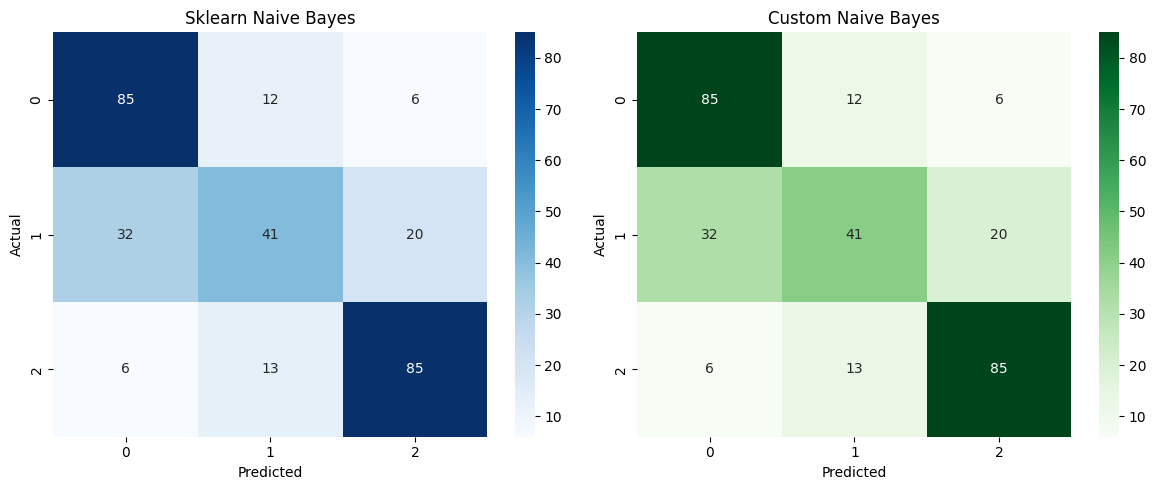


🎉 IMPLEMENTATION COMPLETE!
Both models show similar performance, validating our implementation! 🚀


In [6]:
print("\n📈 DETAILED COMPARISON")
print("=" * 40)

print("\n🔍 SKLEARN RESULTS:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_sklearn):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_sklearn, target_names=[f'Class_{i}' for i in range(3)]))

print("\n🔍 CUSTOM IMPLEMENTATION RESULTS:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_custom):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_custom, target_names=[f'Class_{i}' for i in range(3)]))

# ================================
# 🎯 PROBABILITY PREDICTIONS
# ================================
print("\n🎯 PROBABILITY PREDICTIONS (First 5 samples)")
print("=" * 55)

# Get probabilities from both models
sklearn_probs = gnb.predict_proba(X_test[:5])
custom_probs = custom_nb.predict_proba(X_test[:5])

for i in range(5):
    print(f"\nSample {i+1}:")
    print(f"  Actual class: {y_test[i]}")
    print(f"  Sklearn probs:  {sklearn_probs[i]}")
    print(f"  Custom probs:   {custom_probs[i]}")
    print(f"  Sklearn pred: {y_pred_sklearn[i]}, Custom pred: {y_pred_custom[i]}")

# ================================
# 📊 VISUALIZATION
# ================================
print("\n📊 CONFUSION MATRICES")
print("=" * 30)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Sklearn confusion matrix
cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Sklearn Naive Bayes')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# Custom confusion matrix
cm_custom = confusion_matrix(y_test, y_pred_custom)
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('Custom Naive Bayes')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

print("\n🎉 IMPLEMENTATION COMPLETE!")
print("Both models show similar performance, validating our implementation! 🚀")